In [21]:
import dlib
print("All imports successful!")
!pip install scikit-learn
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report

print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

All imports successful!
All libraries imported successfully!
TensorFlow version: 2.13.0


In [23]:
import os
import cv2

# Define the base dataset directory
base_dir = r'C:\Users\Admin\Downloads\Compressed\FaceForensics++'

# Define video directories
real_video_dir = os.path.join(base_dir, 'real')
fake_video_dir = os.path.join(base_dir, 'fake')

# Define output directories for extracted frames (to be saved in the same main directory)
extracted_real_dir = os.path.join(base_dir, 'extracted_real')
extracted_fake_dir = os.path.join(base_dir, 'extracted_fake')

# Create output directories if they don't exist
os.makedirs(extracted_real_dir, exist_ok=True)
os.makedirs(extracted_fake_dir, exist_ok=True)


In [ ]:

# Function to extract frames from a video file
def extract_frames(video_path, output_dir, frame_interval=30):
    cap = cv2.VideoCapture(video_path)
    count = 0
    saved_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if count % frame_interval == 0:
            filename = os.path.join(output_dir, f'{os.path.basename(video_path).split(".")[0]}_frame_{saved_count:05d}.jpg')
            cv2.imwrite(filename, frame)
            saved_count += 1
        count += 1
    cap.release()
    print(f"Extracted {saved_count} frames from {os.path.basename(video_path)}")

# Process videos in the "real" folder
for file in os.listdir(real_video_dir):
    if file.lower().endswith('.mp4'):
        video_file = os.path.join(real_video_dir, file)
        extract_frames(video_file, extracted_real_dir)

# Process videos in the "fake" folder
for file in os.listdir(fake_video_dir):
    if file.lower().endswith('.mp4'):
        video_file = os.path.join(fake_video_dir, file)
        extract_frames(video_file, extracted_fake_dir)


In [10]:
import os
import shutil

# Define the source directories (where the extracted frames are currently stored)
source_real_dir = os.path.join(base_dir, 'extracted_real')
source_fake_dir = os.path.join(base_dir, 'extracted_fake')

# Define the destination directories (flat structure)
flat_data_dir = os.path.join(base_dir, 'data_flat')
flat_real_dir = os.path.join(flat_data_dir, 'real')
flat_fake_dir = os.path.join(flat_data_dir, 'fake')

# Create the flat directories if they don't exist
os.makedirs(flat_real_dir, exist_ok=True)
os.makedirs(flat_fake_dir, exist_ok=True)


# Function to copy images from nested folders to a flat folder
def flatten_folder(source_dir, dest_dir):
    for root, dirs, files in os.walk(source_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.png')):
                src_file = os.path.join(root, file)
                dest_file = os.path.join(dest_dir, file)
                # In case of duplicate file names, you can add a unique prefix or suffix
                if os.path.exists(dest_file):
                    dest_file = os.path.join(dest_dir, f"{os.path.basename(root)}_{file}")
                shutil.copy(src_file, dest_file)

# Flatten the "real" images
flatten_folder(source_real_dir, flat_real_dir)
# Flatten the "fake" images
flatten_folder(source_fake_dir, flat_fake_dir)

print("Flattening complete. Check the 'data_flat' folder in your FaceForensics++ directory.")


Flattening complete. Check the 'data_flat' folder in your FaceForensics++ directory.


In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the path to the flat dataset directory
data_flat_dir = os.path.join(base_dir, 'data_flat')

# Create an ImageDataGenerator with augmentation and a validation split.
datagen = ImageDataGenerator(
    rescale=1./255,             # Normalize pixel values to [0, 1]
    rotation_range=20,          # Random rotations for augmentation
    width_shift_range=0.2,      # Random horizontal shifts
    height_shift_range=0.2,     # Random vertical shifts
    horizontal_flip=True,       # Random horizontal flips
    validation_split=0.2        # Reserve 20% of data for validation
)

# Create the training data generator
train_generator = datagen.flow_from_directory(
    directory=data_flat_dir,
    target_size=(299, 299),     # Xception expects 299x299 input images
    batch_size=32,
    class_mode='binary',        # Binary classification: real vs fake
    subset='training',          # Use training split (80% of data)
    shuffle=True
)

# Create the validation data generator
validation_generator = datagen.flow_from_directory(
    directory=data_flat_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode='binary',
    subset='validation',        # Use validation split (20% of data)
    shuffle=False
)

print("Data generators created successfully!")


Found 8453 images belonging to 2 classes.
Found 2112 images belonging to 2 classes.
Data generators created successfully!


In [15]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load the pre-trained Xception model without the top layers
base_model = Xception(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

# Freeze the base model layers so they don't get re-trained initially
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Convert the 2D feature maps into a single 1D vector
x = Dense(128, activation='relu')(x)  # Add a fully-connected layer with 128 units
x = Dropout(0.5)(x)  # Add dropout for regularization (prevents overfitting)
predictions = Dense(1, activation='sigmoid')(x)  # Final output layer for binary classification

# Define the complete model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# Print the model summary
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 299, 299, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 149, 149, 32)         864       ['input_1[0][0]']             
                                                                                                  
 block1_conv1_bn (BatchNorm  (None, 149, 149, 32)         128       ['block1_conv1[0][0]']        
 alization)                                                                                       
                                                                                                  
 block1_conv1_act (Activati  (None, 149, 149, 32)         0         ['block1_conv1_bn[0][0]'] 

In [27]:
# Define the number of epochs
epochs = 10  # You can adjust this number based on your experiments

# Train the model using the training and validation generators
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs
)


Epoch 1/10
265/265 [==============================] - 703s 3s/step - loss: 0.6246 - accuracy: 0.6524 - val_loss: 0.8880 - val_accuracy: 0.4579
Epoch 2/10
265/265 [==============================] - 695s 3s/step - loss: 0.5627 - accuracy: 0.7164 - val_loss: 0.8508 - val_accuracy: 0.4749
Epoch 3/10
265/265 [==============================] - 566s 2s/step - loss: 0.5258 - accuracy: 0.7408 - val_loss: 0.8915 - val_accuracy: 0.4792
Epoch 4/10
265/265 [==============================] - 588s 2s/step - loss: 0.5059 - accuracy: 0.7529 - val_loss: 0.9733 - val_accuracy: 0.4782
Epoch 5/10
265/265 [==============================] - 584s 2s/step - loss: 0.4875 - accuracy: 0.7577 - val_loss: 0.9670 - val_accuracy: 0.4806
Epoch 6/10
265/265 [==============================] - 610s 2s/step - loss: 0.4775 - accuracy: 0.7587 - val_loss: 1.0264 - val_accuracy: 0.4740
Epoch 7/10
265/265 [==============================] - 584s 2s/step - loss: 0.4660 - accuracy: 0.7718 - val_loss: 1.0017 - val_accuracy: 0.4910

In [18]:
model.save('xception_deepfake.h5')  # or use .keras or a folder if preferred

C:\Users\Admin\anaconda3\envs\deepfake_detection\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [7]:
from tensorflow.keras.models import load_model
model = load_model('xception_deepfake.h5')

In [29]:
# Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")


66/66 [==============================] - 100s 1s/step - loss: 1.0472 - accuracy: 0.4901
Validation Loss: 1.0472
Validation Accuracy: 0.4901


In [31]:
from sklearn.metrics import confusion_matrix, classification_report

# Reset the validation generator to ensure predictions start from the beginning
validation_generator.reset()

# Get predictions on the validation set
preds = model.predict(validation_generator)
predicted_classes = (preds > 0.5).astype(int).ravel()

# Get true class labels
true_classes = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

# Generate and print the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)
print("Confusion Matrix:")
print(cm)

# Generate and print the classification report
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print("Classification Report:")
print(report)


66/66 [==============================] - 103s 2s/step
Confusion Matrix:
[[730 236]
 [838 308]]
Classification Report:
              precision    recall  f1-score   support

        fake       0.47      0.76      0.58       966
        real       0.57      0.27      0.36      1146

    accuracy                           0.49      2112
   macro avg       0.52      0.51      0.47      2112
weighted avg       0.52      0.49      0.46      2112



In [34]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array

# Path to your test image
test_image_path = r'C:\Users\Admin\Downloads\Doni_3_1.jpeg'
test_image_path = r'C:\Users\Admin\Downloads\Doni_3_1.1.jpeg'
# Load the image using OpenCV
image = cv2.imread(test_image_path)

# Check if image is loaded
if image is None:
    print("Error: Image not found or unable to load.")
else:
    # Convert BGR (OpenCV default) to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Resize image to 299x299 (required for Xception)
    image_resized = cv2.resize(image, (299, 299))
    
    # Convert image to array and normalize to [0, 1]
    image_array = img_to_array(image_resized) / 255.0
    
    # Expand dimensions to match model input shape (1, 299, 299, 3)
    image_input = np.expand_dims(image_array, axis=0)
    
    # Get prediction from the model
    prediction = model.predict(image_input)
    
    # Interpret the result: assuming a threshold of 0.5
    if prediction[0][0] > 0.5:
        print(f"Prediction: {prediction[0][0]:.2f} -> Deepfake (Fake)")
    else:
        print(f"Prediction: {prediction[0][0]:.2f} -> Genuine (Real)")

1/1 [==============================] - 0s 142ms/step
Prediction: 0.66 -> Deepfake (Fake)


1/1 [==============================] - 0s 469ms/step

Visualizing layer: block1_conv2_act - shape: (1, 147, 147, 64)


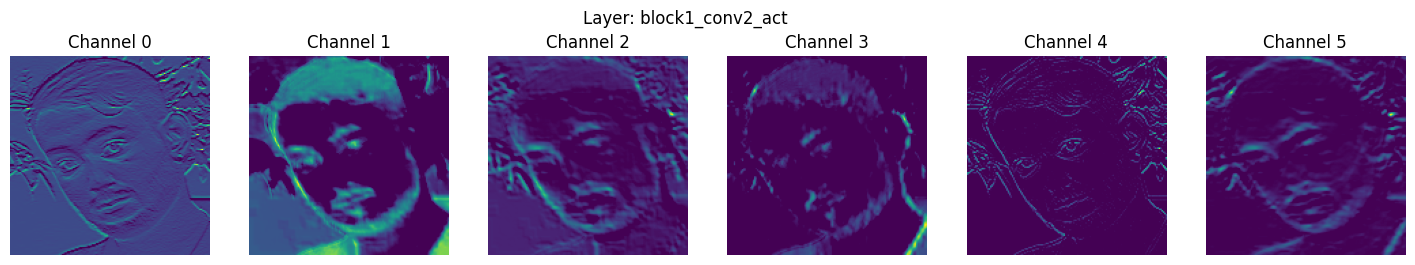


Visualizing layer: block3_sepconv2_act - shape: (1, 74, 74, 256)


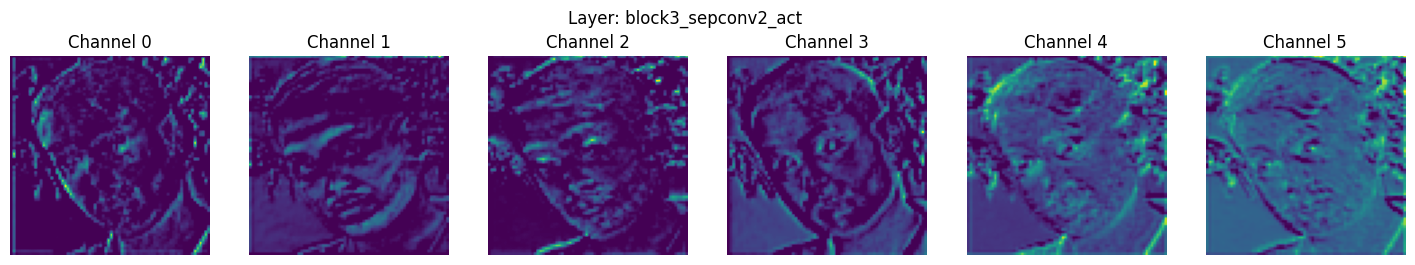


Visualizing layer: block14_sepconv2_act - shape: (1, 10, 10, 2048)


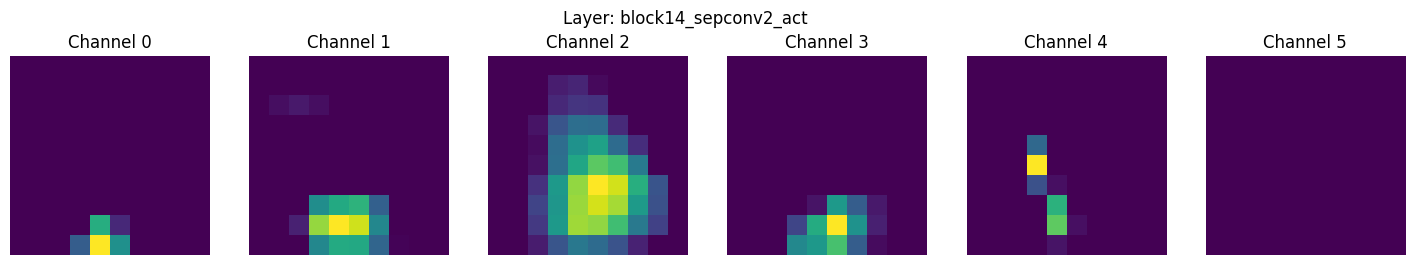

In [33]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing.image import img_to_array

def get_sub_model_outputs(model, layer_names):
    """
    Creates a sub-model that returns the outputs of the specified layers.
    """
    outputs = [model.get_layer(name).output for name in layer_names]
    sub_model = tf.keras.models.Model(inputs=model.input, outputs=outputs)
    return sub_model

def visualize_feature_maps(image_path, model, layer_names):
    """
    1. Loads and preprocesses the image.
    2. Feeds it into a sub-model that outputs intermediate layers.
    3. Displays the activation maps for each chosen layer.
    """
    # Load the image
    original = cv2.imread(image_path)
    if original is None:
        print("Error: Unable to load image.")
        return
    # Convert BGR to RGB and resize to 299x299
    img_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (299, 299))
    
    # Normalize and add batch dimension
    img_array = img_to_array(img_resized) / 255.0
    img_input = np.expand_dims(img_array, axis=0)
    
    # Create the sub-model for the specified layers
    sub_model = get_sub_model_outputs(model, layer_names)
    
    # Get the outputs (feature maps)
    layer_outputs = sub_model.predict(img_input)
    
    for layer_name, feature_map in zip(layer_names, layer_outputs):
        print(f"\nVisualizing layer: {layer_name} - shape: {feature_map.shape}")
        
        # feature_map shape is (1, height, width, channels)
        # Remove batch dimension
        feature_map = feature_map[0]
        
        # We won't display all channels if it's large. Let's just display up to 6 channels.
        num_channels = min(feature_map.shape[-1], 6)
        
        fig, axs = plt.subplots(1, num_channels, figsize=(18, 3))
        fig.suptitle(f"Layer: {layer_name}")
        
        for i in range(num_channels):
            channel_map = feature_map[..., i]
            axs[i].imshow(channel_map, cmap='viridis')
            axs[i].axis('off')
            axs[i].set_title(f"Channel {i}")
        plt.show()

# Example usage:
# Let's pick some layers from Xception to visualize. You can choose any convolutional layers you want.
chosen_layers = [
    'block1_conv2_act',        # Early layer (low-level features)
    'block3_sepconv2_act',     # Mid-level features
    'block14_sepconv2_act'     # Very deep layer (high-level features)
]

test_image_path = r'C:\Users\Admin\Downloads\Doni_3_1.jpeg'

#test_image_path = r'C:\Users\Admin\Downloads\Doni_3_1.1.jpeg'


visualize_feature_maps(test_image_path, model, chosen_layers)


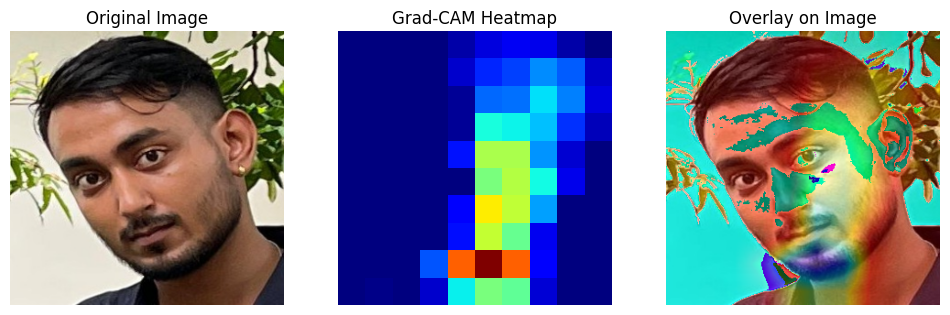

In [35]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations of the last conv layer
    # and the model's predictions.
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    # Compute the gradient of the top predicted class for the input image
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    
    # This is the gradient of the output neuron (for the predicted class)
    # with respect to the output feature map of the last conv layer.
    grads = tape.gradient(class_channel, last_conv_layer_output)
    
    # Pool the gradients over the spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Multiply each channel in the feature map array by the "importance" of that channel
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalize the heatmap between 0 & 1 for visualization.
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def overlay_heatmap(heatmap, image, alpha=0.4, colormap=cv2.COLORMAP_JET):
    # Resize the heatmap to match the image size
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, colormap)
    # Superimpose the heatmap on the original image
    superimposed_img = heatmap * alpha + image
    return np.uint8(superimposed_img)

def gradcam_visualization(image_path, model, last_conv_layer_name):
    # Load and preprocess the image
    image = cv2.imread(image_path)
    if image is None:
        print("Error: Image not found")
        return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image, (299, 299))
    img_array = np.expand_dims(image_resized, axis=0) / 255.0
    
    # Generate the Grad-CAM heatmap
    heatmap = get_gradcam_heatmap(img_array, model, last_conv_layer_name)
    
    # Overlay the heatmap on the original resized image
    superimposed_img = overlay_heatmap(heatmap, image_resized)
    
    # Plot the original image, heatmap, and overlay
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(image_resized)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title("Overlay on Image")
    plt.axis('off')
    plt.show()

# Specify the last convolutional layer in your model. For Xception, a good candidate is 'block14_sepconv2_act'
last_conv_layer_name = 'block14_sepconv2_act'

# Replace with your test image path
test_image_path = r'C:\Users\Admin\Downloads\Doni_3_1.jpeg'

#test_image_path = r'C:\Users\Admin\Downloads\Doni_3_1.1.jpeg'


gradcam_visualization(test_image_path, model, last_conv_layer_name)


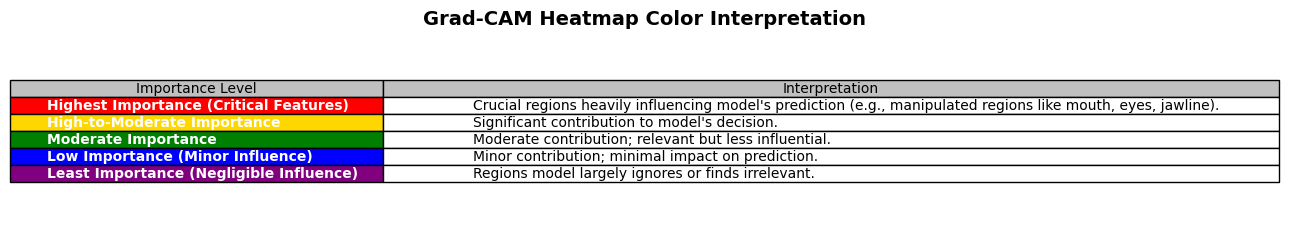

In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define Grad-CAM interpretation details
colors = ['#FF0000', '#FFD700', '#008000', '#0000FF', '#800080']  # Red, Yellow, Green, Blue, Purple
importance_levels = [
    "Highest Importance (Critical Features)",
    "High-to-Moderate Importance",
    "Moderate Importance",
    "Low Importance (Minor Influence)",
    "Least Importance (Negligible Influence)"
]
interpretation = [
    "Crucial regions heavily influencing model's prediction (e.g., manipulated regions like mouth, eyes, jawline).",
    "Significant contribution to model's decision.",
    "Moderate contribution; relevant but less influential.",
    "Minor contribution; minimal impact on prediction.",
    "Regions model largely ignores or finds irrelevant."
]

# Create a figure and axis for the table
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')  # Hide axes

table_data = []
for color, importance, desc in zip(colors, importance_levels, interpretation):
    table_data.append([importance, desc])

table = ax.table(
    cellText=table_data,
    colLabels=["Importance Level", "Interpretation"],
    cellLoc='left',
    loc='center',
    colColours=["#C0C0C0"]*2  # Silver header
)

# Coloring the rows according to Grad-CAM interpretation
for i, color in enumerate(colors):
    table[(i+1, 0)].set_facecolor(color)
    table[(i+1, 0)].set_text_props(color='white', weight='bold')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(table_data[0]))))

plt.title("Grad-CAM Heatmap Color Interpretation", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()